In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from google.colab import drive
import datetime

In [2]:
warnings.filterwarnings('ignore')
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/Input'
OUTPUT_DIR = '/content/drive/MyDrive/CNN_Output'
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
AUGMENTED_DIR = os.path.join(OUTPUT_DIR, 'augmented_data')

Mounted at /content/drive


In [3]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(AUGMENTED_DIR, exist_ok=True)

print("📁 Output directories created:")
print(f"  - Main Output: {OUTPUT_DIR}")
print(f"  - Models: {MODEL_DIR}")
print(f"  - Augmented Data: {AUGMENTED_DIR}")

📁 Output directories created:
  - Main Output: /content/drive/MyDrive/CNN_Output
  - Models: /content/drive/MyDrive/CNN_Output/models
  - Augmented Data: /content/drive/MyDrive/CNN_Output/augmented_data


In [4]:
train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')
dig_path = os.path.join(DATA_DIR, 'Dig-MNIST.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
dig_df = pd.read_csv(dig_path)

In [5]:
pixel_columns = [col for col in train_df.columns if col.startswith("pixel")]

# Prepare training data
X_train_base = train_df[pixel_columns].values / 255.0
y_train_base = train_df["label"].values

# Prepare test data
X_test = test_df[pixel_columns].values / 255.0

# Prepare Dig-MNIST data
X_dig = dig_df[pixel_columns].values / 255.0
y_dig = dig_df["label"].values

# Reshape data from 1D (784) to 2D (28x28x1) for CNN
X_train_base = X_train_base.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_dig = X_dig.reshape(-1, 28, 28, 1)

In [6]:
# Create augmentation pipeline
augmentation_generator = ImageDataGenerator(
    rotation_range=20,           # Random rotation 0-20 degrees
    width_shift_range=0.15,      # Random horizontal shift
    height_shift_range=0.15,     # Random vertical shift
    shear_range=0.15,            # Shear transformation
    zoom_range=0.2,              # Random zoom 0.8-1.2x
    fill_mode='nearest',         # Fill mode for new pixels
    horizontal_flip=False        # No horizontal flip for digits
)

# Combine original + augmented data (multiply dataset)
print("Generating augmented data (this may take a few minutes)...")

augmented_images = []
augmented_labels = []

# Add original data multiple times for extended training
num_augmentation_iterations = 3

for iteration in range(num_augmentation_iterations):
    print(f"  Augmentation iteration {iteration + 1}/{num_augmentation_iterations}")

    # Fit augmentation on original data
    augmentation_generator.fit(X_train_base)

    # Generate augmented batches
    augmented_batch_images = []
    augmented_batch_labels = []

    augment_iterator = augmentation_generator.flow(
        X_train_base, y_train_base,
        batch_size=len(X_train_base),
        shuffle=False
    )

    X_aug_batch, y_aug_batch = next(augment_iterator)
    augmented_batch_images.extend(X_aug_batch)
    augmented_batch_labels.extend(y_aug_batch)

    augmented_images.extend(augmented_batch_images)
    augmented_labels.extend(augmented_batch_labels)

Generating augmented data (this may take a few minutes)...
  Augmentation iteration 1/3
  Augmentation iteration 2/3
  Augmentation iteration 3/3


In [7]:
# Convert to numpy arrays
X_augmented = np.array(augmented_images)
y_augmented = np.array(augmented_labels)

# Combine original + augmented data
X_train_combined = np.vstack([X_train_base, X_augmented])
y_train_combined = np.hstack([y_train_base, y_augmented])

In [8]:

print("\n💾 Saving augmented dataset to Google Drive...")
np.save(os.path.join(AUGMENTED_DIR, 'X_augmented.npy'), X_train_combined)
np.save(os.path.join(AUGMENTED_DIR, 'y_augmented.npy'), y_train_combined)

# Split combined data into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_combined, y_train_combined,
    test_size=0.2,
    random_state=42,
    stratify=y_train_combined
)


💾 Saving augmented dataset to Google Drive...


In [9]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
    layers.ReLU(),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.ReLU(),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.ReLU(),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(256),
    layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(128),
    layers.ReLU(),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(10, activation='softmax')
])



In [10]:
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint callback - save best model
checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, 'best_cnn_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# ==================== TRAIN MODEL ====================
print("\n🚀 Starting training for 7-8 hour window...")
print(f"⏰ Training started at: {datetime.datetime.now()}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,  # Extended epochs for 7-8 hour training window
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print(f"✓ Training completed at: {datetime.datetime.now()}")

# ==================== EVALUATE ON TEST SETS ====================
print("\n📊 Evaluating model...")

# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

# Evaluate on Dig-MNIST set
dig_loss, dig_acc = model.evaluate(X_dig, y_dig, verbose=0)
print(f"\nDig-MNIST Accuracy: {dig_acc:.4f}")
print(f"Dig-MNIST Loss: {dig_loss:.4f}")

# Make predictions
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_dig_pred = np.argmax(model.predict(X_dig), axis=1)

# Classification reports
print("\n" + "="*50)
print("VALIDATION SET CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_val, y_val_pred))

print("\n" + "="*50)
print("DIG-MNIST SET CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_dig, y_dig_pred))

# ==================== SAVE RESULTS ====================
print("\n💾 Saving results to Google Drive...")

# Save final model
final_model_path = os.path.join(MODEL_DIR, 'cnn_model_final.h5')
model.save(final_model_path)
print(f"✓ Model saved: {final_model_path}")

# Save training history
history_path = os.path.join(OUTPUT_DIR, 'training_history.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)
print(f"✓ Training history saved: {history_path}")

# Save predictions
predictions_data = {
    'X_dig': X_dig,
    'y_dig': y_dig,
    'y_dig_pred': y_dig_pred,
    'dig_accuracy': dig_acc,
    'val_accuracy': val_acc
}
pred_path = os.path.join(OUTPUT_DIR, 'predictions.pkl')
with open(pred_path, 'wb') as f:
    pickle.dump(predictions_data, f)
print(f"✓ Predictions saved: {pred_path}")


🚀 Starting training for 7-8 hour window...
⏰ Training started at: 2025-11-07 22:19:54.376213
Epoch 1/200
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7768 - loss: 0.6320
Epoch 1: val_accuracy improved from -inf to 0.98990, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.7772 - loss: 0.6307 - val_accuracy: 0.9899 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 2/200
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9841 - loss: 0.0607
Epoch 2: val_accuracy improved from 0.98990 to 0.99163, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9841 - loss: 0.0607 - val_accuracy: 0.9916 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 3/200
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9879 - loss: 0.0454
Epoch 3: val_accuracy did not improve from 0.99163
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9879 - loss: 0.0454 - val_accuracy: 0.9915 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 4/200
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9898 - loss: 0.0377
Epoch 4: val_accuracy did not improve from 0.99163
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9898 - loss: 0.0377 - val_accuracy: 0.9911 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 5/200
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9906 - loss: 0.0338
Epoch 5: val_accuracy improved from 0.99163 to 0.99244, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9906 - loss: 0.0338 - val_accuracy: 0.9924 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 6/200
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9918 - loss: 0.0290
Epoch 6: val_accuracy improved from 0.99244 to 0.99415, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9918 - loss: 0.0290 - val_accuracy: 0.9941 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 7/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9922 - loss: 0.0290
Epoch 7: val_accuracy did not improve from 0.99415
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9922 - loss: 0.0290 - val_accuracy: 0.9928 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 8/200
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9931 - loss: 0.0244
Epoch 8: val_accuracy did not improve from 0.99415
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9931 - loss: 0.0244 - val_accuracy: 0.9930 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 9/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9931 - loss: 0.0245
Epoch 9: val_accuracy did not improve from 0.99415
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9931 - loss: 0.0245 - val_accuracy: 0.9937 - val_loss: 0.0202 - learning_rate: 0.00

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.9964 - val_loss: 0.0177 - learning_rate: 2.5000e-04
Epoch 28/200
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9987 - loss: 0.0042
Epoch 28: val_accuracy improved from 0.99638 to 0.99640, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9964 - val_loss: 0.0181 - learning_rate: 1.2500e-04
Epoch 29/200
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9989 - loss: 0.0038
Epoch 29: val_accuracy improved from 0.99640 to 0.99650, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 0.9965 - val_loss: 0.0182 - learning_rate: 1.2500e-04
Epoch 30/200
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9988 - loss: 0.0044
Epoch 30: val_accuracy did not improve from 0.99650
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9988 - loss: 0.0044 - val_accuracy: 0.9964 - val_loss: 0.0176 - learning_rate: 1.2500e-04
Epoch 31/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9991 - loss: 0.0028
Epoch 31: val_accuracy improved from 0.99650 to 0.99663, saving model to /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9966 - val_loss: 0.0180 - learning_rate: 1.2500e-04
Epoch 32/200
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9990 - loss: 0.0038
Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 32: val_accuracy did not improve from 0.99663
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9963 - val_loss: 0.0181 - learning_rate: 1.2500e-04
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 17.
✓ Training completed at: 2025-11-07 22:29:29.799001

📊 Evaluating model...

Validation Accuracy: 0.9956
Validation Loss: 0.0157

Dig-MNIST Accuracy: 0.9090
Dig-MNIST Loss: 0.6952
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

VALIDATION SET CLASSIFICATION REPORT


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4800
           1       0.99      1.00      0.99      4800
           2       1.00      1.00      1.00      4800
           3       1.00      1.00      1.00      4800
           4       1.00      1.00      1.00      4800
           5       1.00      1.00      1.00      4800
           6       0.99      0.99      0.99      4800
           7       0.99      0.99      0.99      4800
           8       1.00      1.00      1.00      4800
           9       1.00      0.99      0.99      4800

    accuracy                           1.00     48000
   macro avg       1.00      1.00      1.00     48000
weighted avg       1.00      1.00      1.00     48000


DIG-MNIST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1024
           1       0.92      0.87      0.89      1024
           2       0.93      0.94      0.

✓ Plots saved: /content/drive/MyDrive/CNN_Output/training_results.png


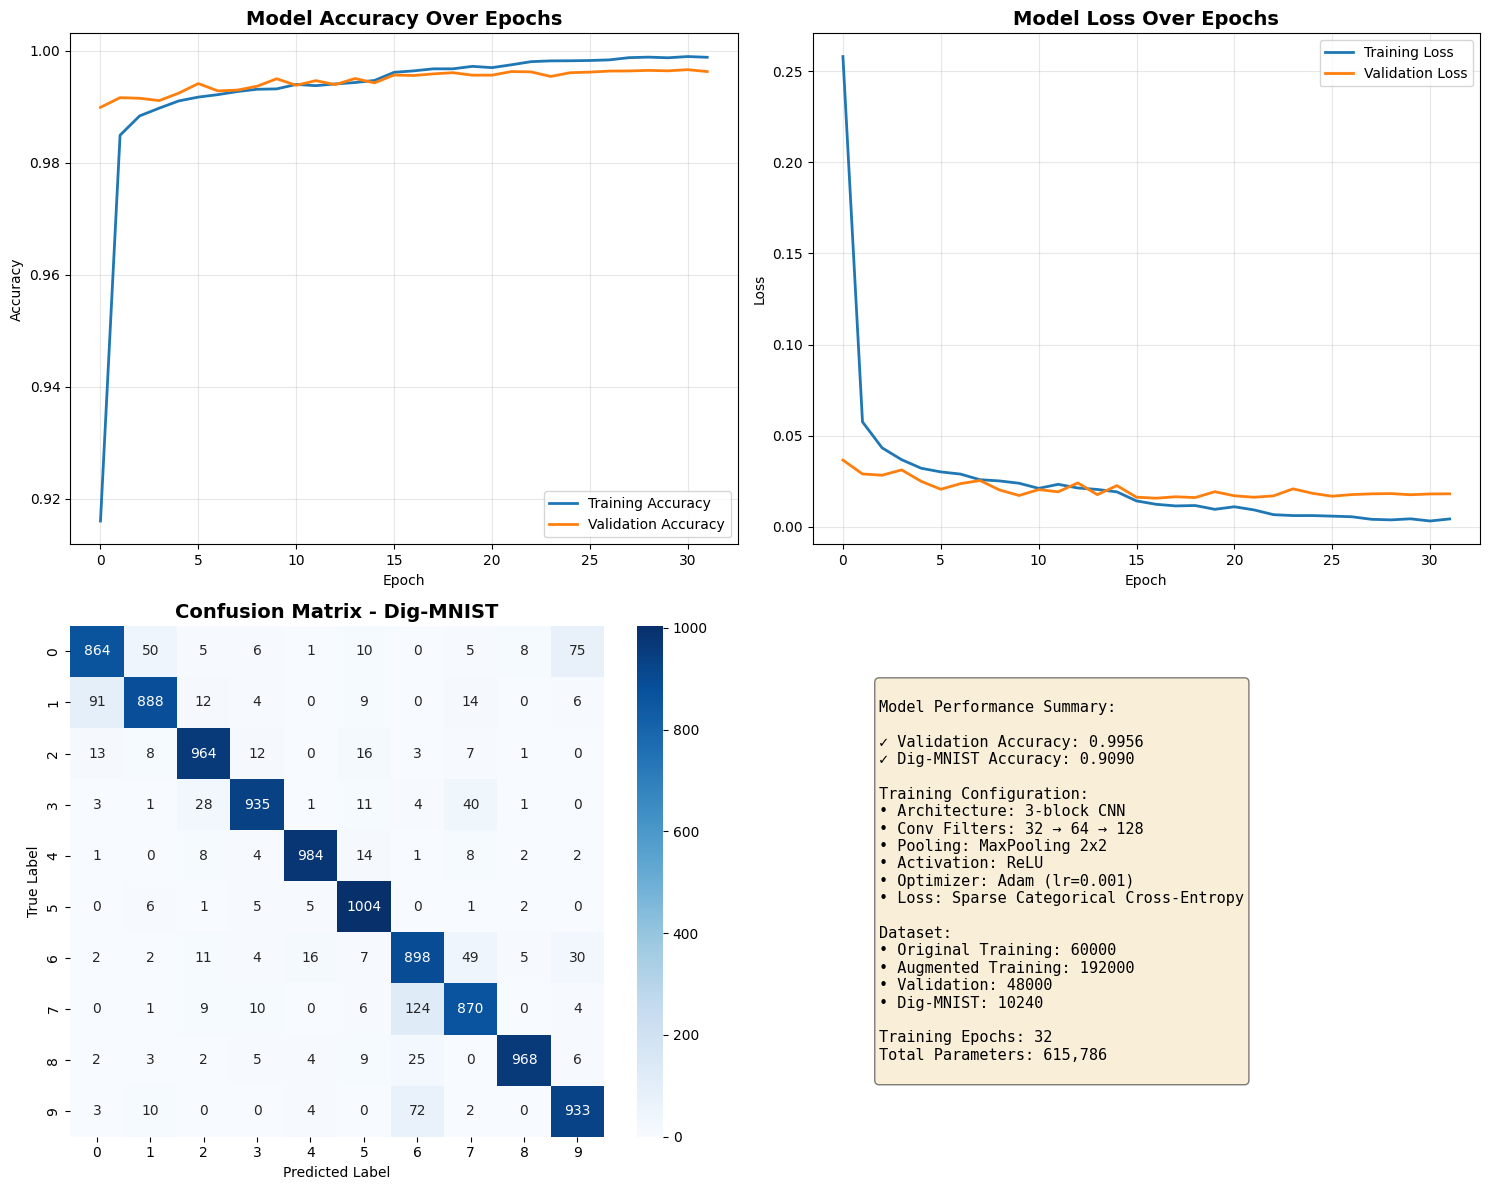

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training and Validation Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training and Validation Loss
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Confusion Matrix for Dig-MNIST
cm = confusion_matrix(y_dig, y_dig_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=True)
axes[1, 0].set_title('Confusion Matrix - Dig-MNIST', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Plot 4: Sample Predictions
sample_indices = np.random.choice(len(X_dig), 10, replace=False)
axes[1, 1].axis('off')
accuracy_text = f"""
Model Performance Summary:

✓ Validation Accuracy: {val_acc:.4f}
✓ Dig-MNIST Accuracy: {dig_acc:.4f}

Training Configuration:
• Architecture: 3-block CNN
• Conv Filters: 32 → 64 → 128
• Pooling: MaxPooling 2x2
• Activation: ReLU
• Optimizer: Adam (lr=0.001)
• Loss: Sparse Categorical Cross-Entropy

Dataset:
• Original Training: {X_train_base.shape[0]}
• Augmented Training: {X_train.shape[0]}
• Validation: {X_val.shape[0]}
• Dig-MNIST: {X_dig.shape[0]}

Training Epochs: {len(history.history['loss'])}
Total Parameters: {model.count_params():,}
"""
axes[1, 1].text(0.1, 0.5, accuracy_text, fontsize=11, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_results.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Plots saved: {plot_path}")
plt.show()


In [13]:
print("\n" + "="*60)
print("🎉 CNN TRAINING COMPLETE!")
print("="*60)
print(f"\n📊 Final Results:")
print(f"   Validation Accuracy: {val_acc:.4f}")
print(f"   Dig-MNIST Accuracy: {dig_acc:.4f}")
print(f"\n💾 Saved Files:")
print(f"   ✓ Model: {final_model_path}")
print(f"   ✓ Best Model: {os.path.join(MODEL_DIR, 'best_cnn_model.h5')}")
print(f"   ✓ Training History: {history_path}")
print(f"   ✓ Predictions: {pred_path}")
print(f"   ✓ Visualizations: {plot_path}")
print(f"   ✓ Augmented Data: {AUGMENTED_DIR}")
print(f"\n🎯 All outputs saved to Google Drive: {OUTPUT_DIR}")
print("="*60)


🎉 CNN TRAINING COMPLETE!

📊 Final Results:
   Validation Accuracy: 0.9956
   Dig-MNIST Accuracy: 0.9090

💾 Saved Files:
   ✓ Model: /content/drive/MyDrive/CNN_Output/models/cnn_model_final.h5
   ✓ Best Model: /content/drive/MyDrive/CNN_Output/models/best_cnn_model.h5
   ✓ Training History: /content/drive/MyDrive/CNN_Output/training_history.pkl
   ✓ Predictions: /content/drive/MyDrive/CNN_Output/predictions.pkl
   ✓ Visualizations: /content/drive/MyDrive/CNN_Output/training_results.png
   ✓ Augmented Data: /content/drive/MyDrive/CNN_Output/augmented_data

🎯 All outputs saved to Google Drive: /content/drive/MyDrive/CNN_Output


In [15]:
print("\n🔄 Testing model loading capability...")

# Load the saved model to verify
loaded_model = keras.models.load_model(os.path.join(MODEL_DIR, 'best_cnn_model.h5'))
print("✓ Model successfully loaded!")

# Test on a few samples
test_predictions = loaded_model.predict(X_dig[:5])
test_pred_classes = np.argmax(test_predictions, axis=1)
print(f"✓ Test predictions on 5 samples: {test_pred_classes}")
print(f"✓ Actual labels: {y_dig[:5]}")



🔄 Testing model loading capability...


✓ Model successfully loaded!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
✓ Test predictions on 5 samples: [0 1 2 3 4]
✓ Actual labels: [0 1 2 3 4]
